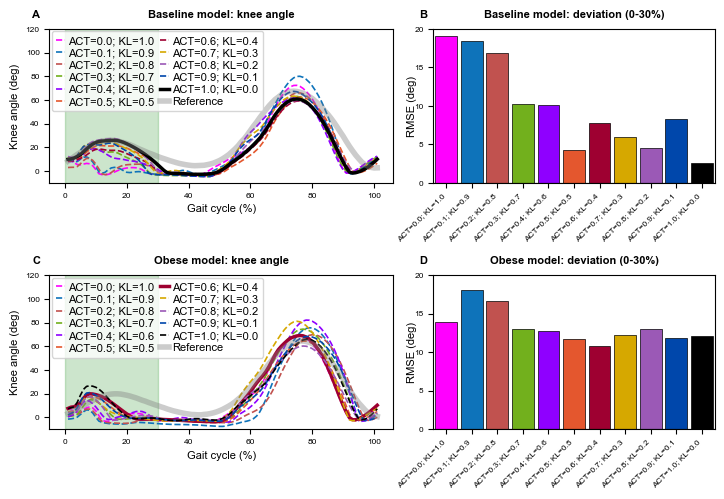

In [1]:
# Figure 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.lines import Line2D
from sklearn.metrics import mean_squared_error
import matplotlib as mpl

# --- Global Style Settings ---
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 8
mpl.rcParams["xtick.labelsize"] = 6
mpl.rcParams["ytick.labelsize"] = 6

def load_and_process(simdata_path, rmse_path, solid_line, override_color, shared_color_map):
    simdata_df = pd.read_csv(simdata_path)
    rmse_df = pd.read_csv(rmse_path).drop(columns=["Index"], errors="ignore")

    stance_phase = simdata_df.iloc[:, 0]
    KF_columns = [col for col in simdata_df.columns if "KF" in col and "ACT" in col]
    REF_col = "REF"
    REF = simdata_df[REF_col]

    rmse_df_trim = rmse_df.iloc[0:31]
    reference = rmse_df_trim[REF_col]
    rmse_results = {
        col: mean_squared_error(reference, rmse_df_trim[col], squared=False)
        for col in KF_columns
        if col in rmse_df_trim.columns
    }
    ordered_rmse = dict(sorted(rmse_results.items(), key=lambda x: x[1]))

    return stance_phase, simdata_df, REF, KF_columns, solid_line, ordered_rmse

def build_legend_handles(kf_columns, solid_line, bar_color_map):
    handles = []
    for col in kf_columns:
        label = col.split("_", 1)[-1]
        act = float(label.split("ACT(")[1].split(")")[0])
        kl = float(label.split("KF(")[1].split(")")[0])
        label_key = f"ACT={act}; KL={kl}"
        color = bar_color_map.get(label_key, "black")
        if label == "ACT(0.0)+KF(1.0)":
            color = "magenta"

        linestyle = "-" if col == solid_line else "--"
        linewidth = 2.5 if col == solid_line else 1.2

        handles.append(
            Line2D([], [], color=color, linestyle=linestyle, linewidth=linewidth, label=label_key)
        )

    handles.append(
        Line2D([], [], color="gray", linestyle="-", linewidth=4, alpha=0.4, label="Reference")
    )
    return handles

def plot_2x2(simdata_80_path, rmse_80_path, simdata_140_path, rmse_140_path):
    color_palette = [
        "magenta", "#0E73BA", "#C1524F", "#72B01D", "#8F00FF",
        "#E4572E", "#9E0031", "#D6A800", "#9B59B6", "#0047AB", "black"
    ]

    fig = plt.figure(figsize=(5.04, 4.6))
    spec = gridspec.GridSpec(nrows=2, ncols=2, figure=fig, width_ratios=[5.5, 4.5])
    axs = np.array([
        [fig.add_subplot(spec[0, 0]), fig.add_subplot(spec[0, 1])],
        [fig.add_subplot(spec[1, 0]), fig.add_subplot(spec[1, 1])]
    ])
    fig.subplots_adjust(left=0.08, right=1.4, top=0.95, bottom=0.08, wspace=0.13, hspace=0.6)

    data_80 = load_and_process(simdata_80_path, rmse_80_path, "80kg_ACT(1.0)+KF(0.0)", "#EEBA4C", {})
    data_140 = load_and_process(simdata_140_path, rmse_140_path, "140kg_ACT(0.6)+KF(0.4)", "#EEBA4C", {})

    display_labels = [
        "ACT=0.0; KL=1.0", "ACT=0.1; KL=0.9", "ACT=0.2; KL=0.8",
        "ACT=0.3; KL=0.7", "ACT=0.4; KL=0.6", "ACT=0.5; KL=0.5",
        "ACT=0.6; KL=0.4", "ACT=0.7; KL=0.3", "ACT=0.8; KL=0.2",
        "ACT=0.9; KL=0.1", "ACT=1.0; KL=0.0"
    ]
    num_bars = len(display_labels)
    if num_bars > len(color_palette):
        color_palette = color_palette * (num_bars // len(color_palette)) + color_palette[: num_bars % len(color_palette)]
    bar_color_map = {display_labels[i]: color_palette[i] for i in range(num_bars)}
    bar_color_map["ACT=1; KL=0"] = "black"

    title_y = 1.0
    panel_x = -0.05
    panel_y = 1.06

    for row, (stance_phase, simdata_df, REF, KF_columns, solid_line, ordered_rmse) in enumerate([data_80, data_140]):
        ax = axs[row, 0]
        panel_label = "A" if row == 0 else "C"
        title_text = "Baseline model: knee angle" if row == 0 else "Obese model: knee angle"

        ax.text(
            panel_x, panel_y, panel_label,
            transform=ax.transAxes,
            fontsize=8,
            fontweight='bold',
            ha='left',
            va='bottom',
            clip_on=False
        )
        ax.set_title(
            title_text,
            fontsize=8, fontweight='bold', pad=8, loc="center", y=title_y
        )

        for col in KF_columns:
            label = col.split("_", 1)[-1]
            linestyle = "-" if col == solid_line else "--"
            linewidth = 2.5 if col == solid_line else 1.2
            label_act = float(label.split("ACT(")[1].split(")")[0])
            label_kf = float(label.split("KF(")[1].split(")")[0])
            label_key = f"ACT={label_act}; KL={label_kf}"
            color = bar_color_map.get(label_key, "black")
            if label == "ACT(0.0)+KF(1.0)":
                color = "magenta"

            ax.plot(
                stance_phase,
                simdata_df[col],
                label=label_key,
                color=color,
                linestyle=linestyle,
                linewidth=linewidth,
            )

        ax.plot(
            stance_phase,
            REF,
            label="Reference",
            color="gray",
            linewidth=4,
            alpha=0.4,
        )
        ax.axvspan(0, 30, color="green", alpha=0.2)

        ax.set_xlabel("Gait cycle (%)", fontsize=8)
        ax.set_ylabel("Knee angle (deg)", fontsize=8)
        ax.set_ylim(-10, 120)
        ax.set_yticks([0, 20, 40, 60, 80, 100, 120])
        legend_handles = build_legend_handles(KF_columns, solid_line, bar_color_map)
        ax.legend(
        handles=legend_handles,
        fontsize=8,
        loc="upper left",
        ncol=2,
        handlelength=0.8,
        handletextpad=0.3,
        columnspacing=0.5,
        labelspacing=0.2,
        borderaxespad=0.2,
        frameon=True
    )
        ax = axs[row, 1]
        panel_label = "B" if row == 0 else "D"
        title_text = "Baseline model: deviation (0-30%)" if row == 0 else "Obese model: deviation (0-30%)"

        ax.text(
            panel_x, panel_y, panel_label,
            transform=ax.transAxes,
            fontsize=8,
            fontweight='bold',
            ha='left',
            va='bottom',
            clip_on=False
        )
        ax.set_title(
            title_text,
            fontsize=8, fontweight='bold', pad=8, loc="center", y=title_y
        )

        ordered_rmse_sorted = sorted(
            ordered_rmse.items(),
            key=lambda x: (
                float(x[0].split("ACT(")[1].split(")")[0]),
                float(x[0].split("KF(")[1].split(")")[0]),
            ),
        )
        labels = [
            f"ACT={float(item[0].split('ACT(')[1].split(')')[0])}; "
            f"KL={float(item[0].split('KF(')[1].split(')')[0])}"
            for item in ordered_rmse_sorted
        ]
        bar_colors = [bar_color_map.get(label, "black") for label in labels]
        values = [item[1] for item in ordered_rmse_sorted]

        x = np.arange(len(labels))
        ax.bar(x, values, color=bar_colors, width=0.85, edgecolor="black", linewidth=0.5)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_ylabel("RMSE (deg)", fontsize=8)
        ax.yaxis.set_label_coords(-0.06, 0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=6)
        ax.set_xlim(-0.5, len(labels) - 0.5)
        ax.set_ylim(0, 20)
        ax.set_yticks([0, 5, 10, 15, 20])
        

    
    plt.savefig("Figure1.tiff", dpi=1000, bbox_inches="tight")
    plt.show()

plot_2x2(
    "simdata_80kg_RMSE.csv", "simdata_80kg_RMSE.csv",
    "simdata_140kg_RMSE.csv", "simdata_140kg_RMSE.csv"
)


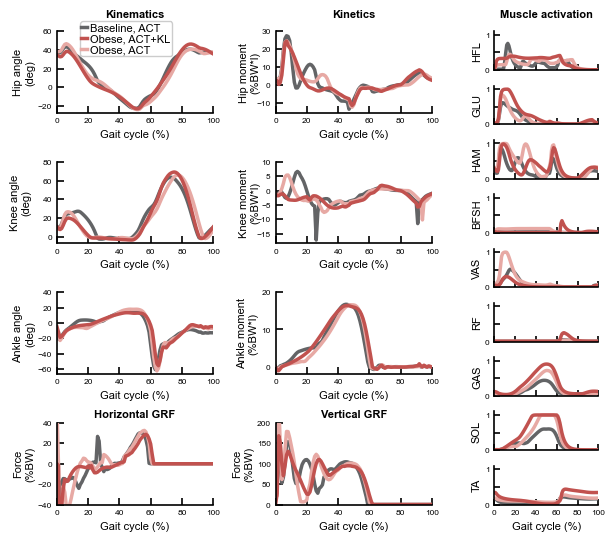

In [2]:
# Figure 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib as mpl
import re
import os

# === Set global font to Arial ===
mpl.rcParams['font.family'] = 'Arial'

# === Normalize DataFrame ===
def normalize_dataframe(df):
    normalized_df = pd.DataFrame()
    original_len = len(df)
    x_original = np.linspace(0, original_len - 1, original_len)
    x_new = np.linspace(0, original_len - 1, 101)
    for col in df.columns:
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(series) == 0:
            continue
        valid_length = min(len(series), len(x_original))
        interpolated = np.interp(x_new, x_original[:valid_length], series[:valid_length])
        normalized_df[col] = interpolated
    return normalized_df

# === Clean filename to valid variable name ===
def clean_name(filepath):
    name = os.path.splitext(os.path.basename(filepath))[0]
    name = re.sub(r'[^0-9a-zA-Z_]', '_', name)
    return name

# === Load + Normalize in one step ===
def load_and_normalize(filepath, sheet="Sheet1"):
    df = pd.read_excel(filepath, sheet_name=sheet)
    return normalize_dataframe(df)

# === File paths ===
file1 = "plotdata_140kg(ACT).xlsx"
file2 = "plotdata_140kg(ACT+KL).xlsx"
file3 = "plotdata_control(80kg).xlsx"

# === Create dynamic variable names ===
df1_name = clean_name(file1)
df2_name = clean_name(file2)
df3_name = clean_name(file3)

globals()[df1_name] = load_and_normalize(file1)
globals()[df2_name] = load_and_normalize(file2)
globals()[df3_name] = load_and_normalize(file3)

# For easier reference in plotting:
df_obese_ACT = globals()[df1_name]
df_obese_ACTKF = globals()[df2_name]
df_control80 = globals()[df3_name]

# === New Time Array ===
time = np.linspace(0, 100, 101)

# === Plot Labels ===
col1_titles = ["Hip Angle", "Knee Angle", "Ankle Angle", "Horizontal GRF"]
col2_titles = ["Hip Moment", "Knee Moment", "Ankle Moment", "Vertical GRF"]
col3_titles = ["HFL", "GLU", "HAM", "BFSH", "VAS", "RF", "GAS", "SOL", "TA"]

display_titles = {
    "Hip Angle": "Hip angle",
    "Knee Angle": "Knee angle",
    "Ankle Angle": "Ankle angle",
    "Horizontal GRF": "Horizontal GRF",
    "Hip Moment": "Hip moment",
    "Knee Moment": "Knee moment",
    "Ankle Moment": "Ankle moment",
    "Vertical GRF": "Vertical GRF",
}

ylabels = {
    "Hip Angle": "Hip angle\n(deg)",
    "Knee Angle": "Knee angle\n(deg)",
    "Ankle Angle": "Ankle angle\n(deg)",
    "Hip Moment": "Hip moment\n(%BW*l)",
    "Knee Moment": "Knee moment\n(%BW*l)",
    "Ankle Moment": "Ankle moment\n(%BW*l)",
    "Horizontal GRF": "Force\n(%BW)",
    "Vertical GRF": "Force\n(%BW)",
}

ytick_values = {
    "Hip Angle": [-20, 0, 20, 40, 60],
    "Knee Angle": [0, 20, 40, 60, 80],
    "Ankle Angle": [-60, -40, -20, 0, 20, 40],
    "Horizontal GRF": [-40, -20, 0, 20, 40],
    "Hip Moment": [-10, 0, 10, 20, 30],
    "Knee Moment": [-15, -10, -5, 0, 5, 10],
    "Ankle Moment": [0, 10, 20],
    "Vertical GRF": [0, 50, 100, 150, 200]
}

ylimits = {
    "Horizontal GRF": (-40, 40),
    "Vertical GRF": (0, 200)
}

# === Create figure ===
fig = plt.figure(figsize=(5.76, 5.2), facecolor="white")
outer = gridspec.GridSpec(
    nrows=4, ncols=3,
    width_ratios=[1.2, 1.2, 0.8],
    height_ratios=[1.1, 1.1, 1.1, 1.1],
    wspace=0.45,
    hspace=0.6
)

# === Font settings ===
label_font = {'fontsize': 8}
tick_fontsize = 6
labelpad_val = 2
subplot_title_y = 1.04

color_black = '#636466'
color_yellow = '#e7a9a4'
color_red = '#C1524F'

# === Legend handles ===
line_control80 = Line2D([], [], color=color_black, linewidth=2.5, label='Baseline, ACT')
line_obese_ACT = Line2D([], [], color=color_yellow, linewidth=2.5, label='Obese, ACT')
line_obese_ACTKF = Line2D([], [], color=color_red, linewidth=2.5, label='Obese, ACT+KL')

def style_axis(ax, tick_length=5):
    ax.tick_params(labelsize=tick_fontsize, direction='in', length=tick_length, width=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

# === Column titles ===
ax_title1 = fig.add_subplot(outer[0, 0])
ax_title1.set_title("Kinematics", fontsize=8, fontweight='bold', pad=10)
ax_title1.axis('off')

ax_title2 = fig.add_subplot(outer[0, 1])
ax_title2.set_title("Kinetics", fontsize=8, fontweight='bold', pad=10)
ax_title2.axis('off')

legend_added = False

# === Columns 1 and 2 ===
for col, titles in zip([0, 1], [col1_titles, col2_titles]):
    for i, label in enumerate(titles):
        ax = fig.add_subplot(outer[i, col])
        if all(label in df.columns for df in [df_obese_ACT, df_obese_ACTKF, df_control80]):
            ax.plot(time, df_control80[label], color=color_black, linewidth=2.5)
            ax.plot(time, df_obese_ACT[label], color=color_yellow, linewidth=2.5)
            ax.plot(time, df_obese_ACTKF[label], color=color_red, linewidth=2.5)

            ax.set_xlim(0, 100)
            ax.set_xticks([0, 20, 40, 60, 80, 100])

            if "GRF" in label:
                ax.text(
                    0.5, subplot_title_y, display_titles[label],
                    transform=ax.transAxes,
                    fontsize=8,
                    fontweight='bold',
                    ha='center',
                    va='bottom'
                )

            pad = labelpad_val
            if label == "Knee Angle":
                pad += 6
            if label in ["Knee Moment", "Hip Moment"]:
                pad -= 5

            ax.set_ylabel(ylabels[label], labelpad=pad, **label_font)

            if label in ytick_values:
                ax.set_yticks(ytick_values[label])

            if label in ylimits:
                ax.set_ylim(ylimits[label])

            ax.set_xlabel("Gait cycle (%)", **label_font)
            ax.set_xticklabels(["0", "20", "40", "60", "80", "100"])
            ax.margins(x=0)

            style_axis(ax, tick_length=5)

            if not legend_added and label == "Hip Angle":
                leg = fig.legend(
                    handles=[line_control80, line_obese_ACTKF, line_obese_ACT],
                    loc='upper center',
                    bbox_to_anchor=(0.16, 0.97),
                    fontsize=8,
                    frameon=True,
                    borderpad=0.1,
                    handlelength=0.5,
                    handletextpad=0.3,
                    labelspacing=0.1,
                    columnspacing=0.70
                )
                leg.set_zorder(100)
                leg.get_frame().set_alpha(1)
                legend_added = True

# === Column 3: Muscle Activation ===
inner = gridspec.GridSpecFromSubplotSpec(9, 1, subplot_spec=outer[:, 2], hspace=0.4)

title_ax = fig.add_subplot(inner[0])
title_ax.set_title("Muscle activation", fontsize=8, fontweight='bold', pad=10)
title_ax.axis('off')

for i, label in enumerate(col3_titles):
    ax = fig.add_subplot(inner[i])
    if all(label in df.columns for df in [df_obese_ACT, df_obese_ACTKF, df_control80]):
        ax.plot(time, df_control80[label], color=color_black, linewidth=2.5)
        ax.plot(time, df_obese_ACT[label], color=color_yellow, linewidth=2.5)
        ax.plot(time, df_obese_ACTKF[label], color=color_red, linewidth=2.5)

        ax.set_xlim(0, 100)
        ax.set_ylim(0, 1.1)
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(['0', '', '1'])
        ax.set_ylabel(label, labelpad=labelpad_val, **label_font)
        ax.set_xticks([0, 20, 40, 60, 80, 100])

        if i == len(col3_titles) - 1:
            ax.set_xlabel("Gait cycle (%)", **label_font)
            ax.set_xticklabels(["0", "20", "40", "60", "80", "100"])
        else:
            ax.set_xticklabels([])

        style_axis(ax, tick_length=4)

    ax.set_facecolor("white")

plt.subplots_adjust(top=0.94, bottom=0.03, left=0.04, right=0.98)
plt.savefig("Figure2.tiff", dpi=1000, bbox_inches='tight', facecolor='white')
plt.show()


In [3]:
import pandas as pd
import numpy as np

def load_normal_cot(path="combined_ACT_data.csv", column="ACT", source="80kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_kot(path="combined_ACT_data.csv", column="KF", source="80kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_sl(path="combined_ACT_data.csv", column="Combined", source="80kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)


def load_obese_cot(path="combined_ACT_data.csv", column="ACT", source="140kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_kot(path="combined_ACT_data.csv", column="KF", source="140kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_sl(path="combined_ACT_data.csv", column="Combined", source="140kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)


def load_obese_cot_D(path="combined_ACT_data.csv", column="ACT", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_kot_E(path="combined_ACT_data.csv", column="KF", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_sl_F(path="combined_ACT_data.csv", column="Combined", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_cot_G(path="combined_ACT_data.csv", column="ACT", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_kot_H(path="combined_ACT_data.csv", column="KF", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_sl_I(path="combined_ACT_data.csv", column="Combined", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)


def load_obese_cot_D(path="combined_ACT_data.csv", column="ACT", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_kot_E(path="combined_ACT_data.csv", column="KF", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_sl_F(path="combined_ACT_data.csv", column="Combined", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)


def load_normal_cot_G(path="combined_ACT_data.csv", column="ACT", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_kot_H(path="combined_ACT_data.csv", column="KF", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_sl_I(path="combined_ACT_data.csv", column="Combined", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)


In [ ]:
# Figure 3
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.lines import Line2D

# === Set global font to Arial ===
mpl.rcParams['font.family'] = 'Arial'

# Shared speed array
speed = np.array([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
speed_smooth = np.linspace(0.75, 1.85, 300)

# Marker size
marker_size = 5

# --- Data for (A) COT ---
normal_COT = load_normal_cot()
obese_COT = load_obese_cot()
poly_COT_normal = np.poly1d(np.polyfit(speed, normal_COT, 2))
poly_COT_obese = np.poly1d(np.polyfit(speed, obese_COT, 2))
smooth_COT_normal = poly_COT_normal(speed_smooth)
smooth_COT_obese = poly_COT_obese(speed_smooth)
min_speed_COT_normal = speed_smooth[np.argmin(smooth_COT_normal)]
min_speed_COT_obese = speed_smooth[np.argmin(smooth_COT_obese)]

# --- Data for (B) KOT ---
normal_KOT = load_normal_kot()
obese_KOT = load_obese_kot()
poly_KOT_normal = np.poly1d(np.polyfit(speed, normal_KOT, 2))
poly_KOT_obese = np.poly1d(np.polyfit(speed, obese_KOT, 2))
smooth_KOT_normal = poly_KOT_normal(speed_smooth)
smooth_KOT_obese = poly_KOT_obese(speed_smooth)
min_speed_KOT_normal = speed_smooth[np.argmin(smooth_KOT_normal)]
min_speed_KOT_obese = speed_smooth[np.argmin(smooth_KOT_obese)]

# --- Data for (C) Combined cost ---
normal_SL = load_normal_sl()
obese_SL = load_obese_sl()
poly_SL_normal = np.poly1d(np.polyfit(speed, normal_SL, 2))
poly_SL_obese = np.poly1d(np.polyfit(speed, obese_SL, 2))
smooth_SL_normal = poly_SL_normal(speed_smooth)
smooth_SL_obese = poly_SL_obese(speed_smooth)
min_speed_SL_normal = speed_smooth[np.argmin(smooth_SL_normal)]
min_speed_SL_obese = speed_smooth[np.argmin(smooth_SL_obese)]

# --- Data for (D) COT (New) ---
normal_COT_D = load_obese_cot_D()
obese_COT_D = load_obese_cot()
poly_COT_normal_D = np.poly1d(np.polyfit(speed, normal_COT_D, 2))
poly_COT_obese_D = np.poly1d(np.polyfit(speed, obese_COT_D, 2))
smooth_COT_normal_D = poly_COT_normal_D(speed_smooth)
smooth_COT_obese_D = poly_COT_obese_D(speed_smooth)
min_speed_COT_normal_D = speed_smooth[np.argmin(smooth_COT_normal_D)]
min_speed_COT_obese_D = speed_smooth[np.argmin(smooth_COT_obese_D)]

# --- Data for (E) KOT (New) ---
normal_KOT_E = load_obese_kot_E()
obese_KOT_E = load_obese_kot()
poly_KOT_normal_E = np.poly1d(np.polyfit(speed, normal_KOT_E, 2))
poly_KOT_obese_E = np.poly1d(np.polyfit(speed, obese_KOT_E, 2))
smooth_KOT_normal_E = poly_KOT_normal_E(speed_smooth)
smooth_KOT_obese_E = poly_KOT_obese_E(speed_smooth)
min_speed_KOT_normal_E = speed_smooth[np.argmin(smooth_KOT_normal_E)]
min_speed_KOT_obese_E = speed_smooth[np.argmin(smooth_KOT_obese_E)]

# --- Data for (F) Combined cost (New) ---
normal_SL_F = load_obese_sl_F()
obese_SL_F = load_obese_sl()
poly_SL_normal_F = np.poly1d(np.polyfit(speed, normal_SL_F, 2))
poly_SL_obese_F = np.poly1d(np.polyfit(speed, obese_SL_F, 2))
smooth_SL_normal_F = poly_SL_normal_F(speed_smooth)
smooth_SL_obese_F = poly_SL_obese_F(speed_smooth)
min_speed_SL_normal_F = speed_smooth[np.argmin(smooth_SL_normal_F)]
min_speed_SL_obese_F = speed_smooth[np.argmin(smooth_SL_obese_F)]

# --- Data for (G) COT ---
normal_COT_G = load_normal_cot()
obese_COT_G = load_normal_cot_G()
poly_COT_normal_G = np.poly1d(np.polyfit(speed, normal_COT_G, 2))
poly_COT_obese_G = np.poly1d(np.polyfit(speed, obese_COT_G, 2))
smooth_COT_normal_G = poly_COT_normal_G(speed_smooth)
smooth_COT_obese_G = poly_COT_obese_G(speed_smooth)
min_speed_COT_normal_G = speed_smooth[np.argmin(smooth_COT_normal_G)]
min_speed_COT_obese_G = speed_smooth[np.argmin(smooth_COT_obese_G)]

# --- Data for (H) KOT ---
normal_KOT_H = load_normal_kot()
obese_KOT_H = load_normal_kot_H()
poly_KOT_normal_H = np.poly1d(np.polyfit(speed, normal_KOT_H, 2))
poly_KOT_obese_H = np.poly1d(np.polyfit(speed, obese_KOT_H, 2))
smooth_KOT_normal_H = poly_KOT_normal_H(speed_smooth)
smooth_KOT_obese_H = poly_KOT_obese_H(speed_smooth)
min_speed_KOT_normal_H = speed_smooth[np.argmin(smooth_KOT_normal_H)]
min_speed_KOT_obese_H = speed_smooth[np.argmin(smooth_KOT_obese_H)]

# --- Data for (I) Combined cost ---
normal_SL_I = load_normal_sl()
obese_SL_I = load_normal_sl_I()
poly_SL_normal_I = np.poly1d(np.polyfit(speed, normal_SL_I, 2))
poly_SL_obese_I = np.poly1d(np.polyfit(speed, obese_SL_I, 2))
smooth_SL_normal_I = poly_SL_normal_I(speed_smooth)
smooth_SL_obese_I = poly_SL_obese_I(speed_smooth)
min_speed_SL_normal_I = speed_smooth[np.argmin(smooth_SL_normal_I)]
min_speed_SL_obese_I = speed_smooth[np.argmin(smooth_SL_obese_I)]

# --- Print precise speeds ---
print("Precise optimal speeds:")
print(f"A baseline, ACT COT: {min_speed_COT_normal:.6f}")
print(f"A obese, ACT+KL COT: {min_speed_COT_obese:.6f}")
print(f"B baseline, ACT KOT: {min_speed_KOT_normal:.6f}")
print(f"B obese, ACT+KL KOT: {min_speed_KOT_obese:.6f}")
print(f"C baseline, ACT combined: {min_speed_SL_normal:.6f}")
print(f"C obese, ACT+KL combined: {min_speed_SL_obese:.6f}")
print(f"D obese, ACT COT: {min_speed_COT_normal_D:.6f}")
print(f"D obese, ACT+KL COT: {min_speed_COT_obese_D:.6f}")
print(f"E obese, ACT KOT: {min_speed_KOT_normal_E:.6f}")
print(f"E obese, ACT+KL KOT: {min_speed_KOT_obese_E:.6f}")
print(f"F obese, ACT combined: {min_speed_SL_normal_F:.6f}")
print(f"F obese, ACT+KL combined: {min_speed_SL_obese_F:.6f}")
print(f"G baseline, ACT COT: {min_speed_COT_normal_G:.6f}")
print(f"G baseline, ACT+KL COT: {min_speed_COT_obese_G:.6f}")
print(f"H baseline, ACT KOT: {min_speed_KOT_normal_H:.6f}")
print(f"H baseline, ACT+KL KOT: {min_speed_KOT_obese_H:.6f}")
print(f"I baseline, ACT combined: {min_speed_SL_normal_I:.6f}")
print(f"I baseline, ACT+KL combined: {min_speed_SL_obese_I:.6f}")

# --- Plotting ---
fig, axes = plt.subplots(3, 3, figsize=(6.8, 6.2))

color_black = '#636466'
color_red = '#C1524F'
color_light_red = '#e7a9a4'
color_light_black = '#b6b8ba'

line_normal = Line2D([], [], color=color_black, linewidth=2.5, label='Baseline, ACT')
line_obese = Line2D([], [], color=color_red, linewidth=2.5, label='Obese, ACT+KL')

line_obese_act = Line2D([], [], color=color_light_red, linewidth=2.5, label='Obese, ACT')
line_obese_actkl = Line2D([], [], color=color_red, linewidth=2.5, label='Obese, ACT+KL')

line_baseline_act = Line2D([], [], color=color_black, linewidth=2.5, label='Baseline, ACT')
line_baseline_actkl = Line2D([], [], color=color_light_black, linewidth=2.5, label='Baseline, ACT+KL')

# Common text positions
letter_x = -0.18
letter_y_top = 1.10
letter_y_lower = 1.10
title_y = 1.16
subtitle_y = 1.05

title_fs = 8
label_fs = 8
tick_fs = 6
legend_fs = 8
subtitle_fs = 8
letter_fs = 8

def draw_speed_annotation(ax, x_left, color_left, x_right, color_right,
                          x_offset_left=0.015, x_offset_right=0.015, y_ratio=0.04):
    y_min, y_max = ax.get_ylim()
    y_text = y_min + y_ratio * (y_max - y_min)

    ax.text(
        x_left - x_offset_left, y_text, f"{x_left:.2f}",
        color=color_left, fontsize=7,
        ha='right', va='bottom'
    )
    ax.text(
        x_right + x_offset_right, y_text, f"{x_right:.2f}",
        color=color_right, fontsize=7,
        ha='left', va='bottom'
    )

# ========== (A) ==========
axes[0, 0].plot(speed_smooth, smooth_COT_normal, '-', color=color_black, linewidth=2.5, zorder=3)
axes[0, 0].plot(speed_smooth, smooth_COT_obese, '-', color=color_red, linewidth=2.5, zorder=3)
axes[0, 0].plot(speed, normal_COT, 'o', color=color_black, markersize=marker_size, zorder=4)
axes[0, 0].plot(speed, obese_COT, 'o', color=color_red, markersize=marker_size, zorder=4)
axes[0, 0].axvline(x=min_speed_COT_normal, color=color_black, linestyle='--', linewidth=2, zorder=1)
axes[0, 0].axvline(x=min_speed_COT_obese, color=color_red, linestyle='--', linewidth=2, zorder=1)

ax = axes[0, 0]
ax.text(letter_x, letter_y_top, "A", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')
ax.text(0.5, title_y, "Muscle effort cost", transform=ax.transAxes, fontweight='bold', fontsize=title_fs, ha='center', va='bottom')
ax.text(0.5, subtitle_y, r"($w_{ACT}$=1.0, $w_{KL}$=0.0)", transform=ax.transAxes, fontsize=subtitle_fs, ha='center', va='bottom')

axes[0, 0].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[0, 0].set_ylabel('Muscle effort (-)', fontsize=label_fs)
axes[0, 0].set_ylim(0, 2)
axes[0, 0].set_yticks([0, 0.5, 1.0, 1.5, 2.0])
axes[0, 0].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[0, 0].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].legend(
    handles=[line_normal, line_obese],
    loc='upper center',
    fontsize=legend_fs,
    frameon=True,
    borderpad=0.2,
    handlelength=1,
    bbox_to_anchor=(0.5, 1.06)
)

# ========== (B) ==========
axes[0, 1].plot(speed_smooth, smooth_KOT_normal, '-', color=color_black, linewidth=2.5, zorder=3)
axes[0, 1].plot(speed_smooth, smooth_KOT_obese, '-', color=color_red, linewidth=2.5, zorder=3)
axes[0, 1].plot(speed, normal_KOT, 'o', color=color_black, markersize=marker_size, zorder=4)
axes[0, 1].plot(speed, obese_KOT, 'o', color=color_red, markersize=marker_size, zorder=4)
axes[0, 1].axvline(x=min_speed_KOT_normal, color=color_black, linestyle='--', linewidth=2, zorder=1)
axes[0, 1].axvline(x=min_speed_KOT_obese, color=color_red, linestyle='--', linewidth=2, zorder=1)

ax = axes[0, 1]
ax.text(letter_x, letter_y_top, "B", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')
ax.text(0.5, title_y, "Knee loading cost", transform=ax.transAxes, fontweight='bold', fontsize=title_fs, ha='center', va='bottom')
ax.text(0.5, subtitle_y, r"($w_{ACT}$=0.0, $w_{KL}$=1.0)", transform=ax.transAxes, fontsize=subtitle_fs, ha='center', va='bottom')

axes[0, 1].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[0, 1].set_ylabel('Knee loading (-)', fontsize=label_fs)
axes[0, 1].set_ylim(0, 8)
axes[0, 1].set_yticks([0, 2, 4, 6, 8])
axes[0, 1].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[0, 1].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# ========== (C) ==========
axes[0, 2].plot(speed_smooth, smooth_SL_normal, '-', color=color_black, linewidth=2.5, zorder=3)
axes[0, 2].plot(speed_smooth, smooth_SL_obese, '-', color=color_red, linewidth=2.5, zorder=3)
axes[0, 2].plot(speed, normal_SL, 'o', color=color_black, markersize=marker_size, zorder=4)
axes[0, 2].plot(speed, obese_SL, 'o', color=color_red, markersize=marker_size, zorder=4)
axes[0, 2].axvline(x=min_speed_SL_normal, color=color_black, linestyle='--', linewidth=2, zorder=1)
axes[0, 2].axvline(x=min_speed_SL_obese, color=color_red, linestyle='--', linewidth=2, zorder=1)

ax = axes[0, 2]
ax.text(letter_x, letter_y_top, "C", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')
ax.text(0.5, title_y, "Combined cost", transform=ax.transAxes, fontsize=title_fs, fontweight='bold', ha='center', va='bottom')
ax.text(0.5, subtitle_y, r"($w_{ACT}$=0.6, $w_{KL}$=0.4)", transform=ax.transAxes, fontsize=subtitle_fs, ha='center', va='bottom')

axes[0, 2].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[0, 2].set_ylabel('Combined cost (-)', fontsize=label_fs)
axes[0, 2].set_ylim(0, 2.5)
axes[0, 2].set_yticks([0, 0.5, 1.0, 1.5, 2.0, 2.5])
axes[0, 2].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[0, 2].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[0, 2].spines['top'].set_visible(False)
axes[0, 2].spines['right'].set_visible(False)

# ========== (D) ==========
axes[1, 0].plot(speed_smooth, smooth_COT_normal_D, '-', color=color_light_red, linewidth=2.5, zorder=3)
axes[1, 0].plot(speed_smooth, smooth_COT_obese_D, '-', color=color_red, linewidth=2.5, zorder=3)
axes[1, 0].plot(speed, normal_COT_D, 'o', color=color_light_red, markersize=marker_size, zorder=4)
axes[1, 0].plot(speed, obese_COT_D, 'o', color=color_red, markersize=marker_size, zorder=4)
axes[1, 0].axvline(x=min_speed_COT_normal_D, color=color_light_red, linestyle='--', linewidth=2, zorder=1)
axes[1, 0].axvline(x=min_speed_COT_obese_D, color=color_red, linestyle='--', linewidth=2, zorder=1)

ax = axes[1, 0]
ax.text(letter_x, letter_y_lower, "D", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')

axes[1, 0].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[1, 0].set_ylabel('Muscle effort (-)', fontsize=label_fs)
axes[1, 0].set_ylim(0, 2)
axes[1, 0].set_yticks([0, 0.5, 1.0, 1.5, 2.0])
axes[1, 0].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[1, 0].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].legend(
    handles=[line_obese_actkl, line_obese_act],
    loc='upper center',
    fontsize=legend_fs,
    frameon=True,
    borderpad=0.2,
    handlelength=1,
    bbox_to_anchor=(0.5, 1.2)
)

# ========== (E) ==========
axes[1, 1].plot(speed_smooth, smooth_KOT_normal_E, '-', color=color_light_red, linewidth=2.5, zorder=3)
axes[1, 1].plot(speed_smooth, smooth_KOT_obese_E, '-', color=color_red, linewidth=2.5, zorder=3)
axes[1, 1].plot(speed, normal_KOT_E, 'o', color=color_light_red, markersize=marker_size, zorder=4)
axes[1, 1].plot(speed, obese_KOT_E, 'o', color=color_red, markersize=marker_size, zorder=4)
axes[1, 1].axvline(x=min_speed_KOT_normal_E, color=color_light_red, linestyle='--', linewidth=2, zorder=1)
axes[1, 1].axvline(x=min_speed_KOT_obese_E, color=color_red, linestyle='--', linewidth=2, zorder=1)

ax = axes[1, 1]
ax.text(letter_x, letter_y_lower, "E", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')

axes[1, 1].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[1, 1].set_ylabel('Knee loading (-)', fontsize=label_fs)
axes[1, 1].set_ylim(0, 8)
axes[1, 1].set_yticks([0, 2, 4, 6, 8])
axes[1, 1].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[1, 1].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

# ========== (F) ==========
axes[1, 2].plot(speed_smooth, smooth_SL_normal_F, '-', color=color_light_red, linewidth=2.5, zorder=3)
axes[1, 2].plot(speed_smooth, smooth_SL_obese_F, '-', color=color_red, linewidth=2.5, zorder=3)
axes[1, 2].plot(speed, normal_SL_F, 'o', color=color_light_red, markersize=marker_size, zorder=4)
axes[1, 2].plot(speed, obese_SL_F, 'o', color=color_red, markersize=marker_size, zorder=4)
axes[1, 2].axvline(x=min_speed_SL_normal_F, color=color_light_red, linestyle='--', linewidth=2, zorder=1)
axes[1, 2].axvline(x=min_speed_SL_obese_F, color=color_red, linestyle='--', linewidth=2, zorder=1)

ax = axes[1, 2]
ax.text(letter_x, letter_y_lower, "F", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')

axes[1, 2].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[1, 2].set_ylabel('Combined cost (-)', fontsize=label_fs)
axes[1, 2].set_ylim(0, 4)
axes[1, 2].set_yticks([0, 1.0, 2.0, 3.0, 4.0])
axes[1, 2].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[1, 2].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[1, 2].spines['top'].set_visible(False)
axes[1, 2].spines['right'].set_visible(False)

# ========== (G) ==========
axes[2, 0].plot(speed_smooth, smooth_COT_normal_G, '-', color=color_black, linewidth=2.5, zorder=3)
axes[2, 0].plot(speed_smooth, smooth_COT_obese_G, '-', color=color_light_black, linewidth=2.5, zorder=3)
axes[2, 0].plot(speed, normal_COT_G, 'o', color=color_black, markersize=marker_size, zorder=4)
axes[2, 0].plot(speed, obese_COT_G, 'o', color=color_light_black, markersize=marker_size, zorder=4)
axes[2, 0].axvline(x=min_speed_COT_normal_G, color=color_black, linestyle='--', linewidth=2, zorder=1)
axes[2, 0].axvline(x=min_speed_COT_obese_G, color=color_light_black, linestyle='--', linewidth=2, zorder=1)

ax = axes[2, 0]
ax.text(letter_x, letter_y_lower, "G", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')

axes[2, 0].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[2, 0].set_ylabel('Muscle effort (-)', fontsize=label_fs)
axes[2, 0].set_ylim(0, 2)
axes[2, 0].set_yticks([0, 0.5, 1.0, 1.5, 2.0])
axes[2, 0].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[2, 0].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[2, 0].spines['top'].set_visible(False)
axes[2, 0].spines['right'].set_visible(False)
axes[2, 0].legend(
    handles=[line_baseline_act, line_baseline_actkl],
    loc='upper center',
    fontsize=legend_fs,
    frameon=True,
    borderpad=0.2,
    handlelength=1,
    bbox_to_anchor=(0.5, 1.2)
)
# ========== (H) ==========
axes[2, 1].plot(speed_smooth, smooth_KOT_normal_H, '-', color=color_black, linewidth=2.5, zorder=3)
axes[2, 1].plot(speed_smooth, smooth_KOT_obese_H, '-', color=color_light_black, linewidth=2.5, zorder=3)
axes[2, 1].plot(speed, normal_KOT_H, 'o', color=color_black, markersize=marker_size, zorder=4)
axes[2, 1].plot(speed, obese_KOT_H, 'o', color=color_light_black, markersize=marker_size, zorder=4)
axes[2, 1].axvline(x=min_speed_KOT_normal_H, color=color_black, linestyle='--', linewidth=2, zorder=1)
axes[2, 1].axvline(x=min_speed_KOT_obese_H, color=color_light_black, linestyle='--', linewidth=2, zorder=1)

ax = axes[2, 1]
ax.text(letter_x, letter_y_lower, "H", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')

axes[2, 1].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[2, 1].set_ylabel('Knee loading (-)', fontsize=label_fs)
axes[2, 1].set_ylim(0, 8)
axes[2, 1].set_yticks([0, 2, 4, 6, 8])
axes[2, 1].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[2, 1].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[2, 1].spines['top'].set_visible(False)
axes[2, 1].spines['right'].set_visible(False)

# ========== (I) ==========
axes[2, 2].plot(speed_smooth, smooth_SL_normal_I, '-', color=color_black, linewidth=2.5, zorder=3)
axes[2, 2].plot(speed_smooth, smooth_SL_obese_I, '-', color=color_light_black, linewidth=2.5, zorder=3)
axes[2, 2].plot(speed, normal_SL_I, 'o', color=color_black, markersize=marker_size, zorder=4)
axes[2, 2].plot(speed, obese_SL_I, 'o', color=color_light_black, markersize=marker_size, zorder=4)
axes[2, 2].axvline(x=min_speed_SL_normal_I, color=color_black, linestyle='--', linewidth=2, zorder=1)
axes[2, 2].axvline(x=min_speed_SL_obese_I, color=color_light_black, linestyle='--', linewidth=2, zorder=1)

ax = axes[2, 2]
ax.text(letter_x, letter_y_lower, "I", transform=ax.transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')

axes[2, 2].set_xlabel('Speed (m/s)', fontsize=label_fs)
axes[2, 2].set_ylabel('Combined cost (-)', fontsize=label_fs)
axes[2, 2].set_ylim(0, 2.5)
axes[2, 2].set_yticks([0, 0.5, 1.0, 1.5, 2.0, 2.5])
axes[2, 2].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[2, 2].tick_params(axis='both', labelsize=tick_fs, direction='in', length=6, width=1)
axes[2, 2].spines['top'].set_visible(False)
axes[2, 2].spines['right'].set_visible(False)

draw_speed_annotation(
    axes[0, 0],
    min_speed_COT_normal, color_black,
    min_speed_COT_obese, color_red,
    x_offset_left=-0.2,
    x_offset_right=-0.2,
    y_ratio=0.05
)

draw_speed_annotation(
    axes[0, 1],
    min_speed_KOT_normal, color_black,
    min_speed_KOT_obese, color_red,
    x_offset_left=-0.2,
    x_offset_right=-0.2,
    y_ratio=0.05
)

draw_speed_annotation(
    axes[0, 2],
    min_speed_SL_normal, color_black,
    min_speed_SL_obese, color_red,
    x_offset_left=-0.2,
    x_offset_right=-0.2,
    y_ratio=0.05
)

draw_speed_annotation(
    axes[1, 0],
    min_speed_COT_normal_D, color_light_red,
    min_speed_COT_obese_D, color_red,
    x_offset_left=-0.2,
    x_offset_right=-0.2,
    y_ratio=0.05
)

draw_speed_annotation(
    axes[1, 1],
    min_speed_KOT_normal_E, color_light_red,
    min_speed_KOT_obese_E, color_red,
    x_offset_left=-0.2,
    x_offset_right=-0.2,
    y_ratio=0.05
)

draw_speed_annotation(
    axes[1, 2],
    min_speed_SL_normal_F, color_light_red,
    min_speed_SL_obese_F, color_red,
    x_offset_left=-0.2,
    x_offset_right=-0.2,
    y_ratio=0.05
)

draw_speed_annotation(
    axes[2, 0],
    min_speed_COT_normal_G, color_black,
    min_speed_COT_obese_G, color_light_black,
    x_offset_left=-0.2,
    x_offset_right=-0.2,
    y_ratio=0.05
)

draw_speed_annotation(
    axes[2, 1],
    min_speed_KOT_normal_H, color_black,
    min_speed_KOT_obese_H, color_light_black,
    x_offset_left=0.03,
    x_offset_right=0.03,
    y_ratio=0.05
)


draw_speed_annotation(
    axes[2, 2],
    min_speed_SL_normal_I, color_black,
    min_speed_SL_obese_I, color_light_black,
    x_offset_left=0.03,
    x_offset_right=0.03,
    y_ratio=0.05
)

# --- Layout and display ---
plt.subplots_adjust(hspace=0.5, wspace=0.35, top=0.92)
plt.savefig("Figure3.tiff", dpi=1000, bbox_inches='tight')
plt.show()


NameError: name 'load_normal_cot_D' is not defined

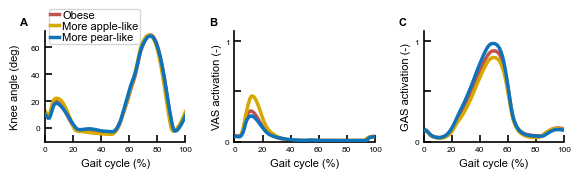

In [ ]:
# Figure 4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

# === Set global font to Arial ===
mpl.rcParams['font.family'] = 'Arial'

# === Normalize DataFrame ===
def normalize_dataframe(df):
    normalized_df = pd.DataFrame()
    original_len = len(df)
    x_original = np.linspace(0, original_len - 1, original_len)
    x_new = np.linspace(0, original_len - 1, 101)
    for col in df.columns:
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(series) == 0:
            continue
        valid_length = min(len(series), len(x_original))
        interpolated = np.interp(x_new, x_original[:valid_length], series[:valid_length])
        normalized_df[col] = interpolated
    return normalized_df

# === Load Data ===
experimental_df = pd.read_excel("plotdata_Apple.xlsx", sheet_name='Sheet1')
control_df = pd.read_excel("plotdata_Pear.xlsx", sheet_name='Sheet1')
kg140_df = pd.read_excel("plotdata_140kg(ACT+KL).xlsx", sheet_name='Sheet1')

experimental_df = normalize_dataframe(experimental_df)
control_df = normalize_dataframe(control_df)
kg140_df = normalize_dataframe(kg140_df)

time = np.linspace(0, 100, 101)

# === Labels ===
top_labels = ["Knee Angle", "VAS", "GAS"]
top_ylabels = {
    "Knee Angle": "Knee angle (deg)",
    "VAS": "VAS activation (-)",
    "GAS": "GAS activation (-)"
}

# === Figure ===
fig, axs = plt.subplots(1, 3, figsize=(5.76, 1.84), sharey=False)

# === Font settings ===
label_font = {'fontsize': 8, 'fontweight': 'normal'}
tick_fontsize = 6
legend_fs = 8
labelpad_val = 8
letter_fs = 8

# === Colors ===
color_obese = '#C1524F'
color_apple = '#D6A800'
color_pear = '#0E73BA'

# === Panel label positions ===
letter_x = -0.18
letter_y = 1.04

# === Legend lines ===
line_kg140 = Line2D([], [], color=color_obese, linewidth=2.5, label='Obese')
line_exp = Line2D([], [], color=color_apple, linewidth=2.5, label='More apple-like')
line_ctrl = Line2D([], [], color=color_pear, linewidth=2.5, label='More pear-like')

def style_left_bottom_axes(ax, tick_length=5):
    ax.tick_params(labelsize=tick_fontsize, direction='in', length=tick_length, width=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

# === Plot panels ===
for i, label in enumerate(top_labels):
    ax = axs[i]

    if label in experimental_df.columns and label in control_df.columns and label in kg140_df.columns:
        ax.plot(time, kg140_df[label], color=color_obese, linewidth=2.5, zorder=1)
        ax.plot(time, experimental_df[label], color=color_apple, linewidth=2.5, zorder=2)
        ax.plot(time, control_df[label], color=color_pear, linewidth=2.5, zorder=3)

        ax.set_xlim(0, 100)
        ax.set_xticks([0, 20, 40, 60, 80, 100])
        ax.set_xticklabels(["0", "20", "40", "60", "80", "100"])
        ax.set_xlabel("Gait cycle (%)", **label_font)
        ax.set_ylabel(top_ylabels[label], labelpad=labelpad_val, **label_font)

        ax.margins(x=0)
        style_left_bottom_axes(ax, tick_length=5)

        if label in ["VAS", "GAS"]:
            ax.set_ylim(0, 1.1)
            ax.set_yticks([0, 0.5, 1.0])
            ax.set_yticklabels(['0', '', '1'])
            ax.yaxis.set_label_coords(-0.089, 0.5)
        elif label == "Knee Angle":
            ax.set_ylim(-10, 72)
            ax.set_yticks([0, 20, 40, 60])

    else:
        ax.axis('off')

# === Legend ===
axs[0].legend(
    handles=[line_kg140, line_exp, line_ctrl],
    loc='upper center',
    fontsize=legend_fs,
    bbox_to_anchor=(0.35, 1.25),
    frameon=True,
    borderpad=0.1,
    handlelength=0.8,
    handletextpad=0.3,
    labelspacing=0.1,
    columnspacing=0.70
    
)

# === Panel labels ===
panel_labels = ['A', 'B', 'C']
for ax, panel in zip(axs.flatten(), panel_labels):
    ax.text(
        letter_x, letter_y, panel,
        transform=ax.transAxes,
        fontsize=letter_fs,
        fontweight='bold',
        ha='left',
        va='bottom'
    )

# === Final adjustment ===
plt.subplots_adjust(top=0.82, bottom=0.22, left=0.08, right=0.98, wspace=0.35)
plt.savefig("Figure4.tiff", dpi=1000, bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import numpy as np

def load_normal_cot(path="combined_ACT_data.csv", column="ACT", source="80kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_kot(path="combined_ACT_data.csv", column="KF", source="80kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_sl(path="combined_ACT_data.csv", column="SL1", source="80kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

normal_SL = load_normal_sl()

print("normal_SL =", normal_SL)



import pandas as pd
import numpy as np

def load_obese_cot(path="combined_ACT_data.csv", column="ACT", source="140kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_kot(path="combined_ACT_data.csv", column="KF", source="140kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_sl(path="combined_ACT_data.csv", column="SL1", source="140kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)


obese_SL = load_obese_sl()


print("obese_SL =", obese_SL)

import pandas as pd
import numpy as np

def load_normal_cot_D(path="combined_ACT_data.csv", column="ACT", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_kot_E(path="combined_ACT_data.csv", column="KF", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_normal_sl_F(path="combined_ACT_data.csv", column="SL1", source="140kg_ACT(1)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)


normal_SL_F = load_normal_sl_F()

print("normal_SL_F =", normal_SL_F)

import pandas as pd
import numpy as np

def load_obese_cot_G(path="combined_ACT_data.csv", column="ACT", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_kot_H(path="combined_ACT_data.csv", column="KF", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

def load_obese_sl_I(path="combined_ACT_data.csv", column="SL1", source="80kg_ACT(0.6)+KF(0.4)"):
    df = pd.read_csv(path)
    if source is not None:
        df = df[df["source_file"] == source]
    if column not in df:
        raise ValueError(f"{column} column not found in {path}")
    return df[column].to_numpy(dtype=float)

obese_SL_I = load_obese_sl_I()

print("obese_SL_I=", obese_SL_I)


normal_SL = [0.60207   0.6938025 0.750775  0.8612955 0.8797235 0.848415 ]
obese_SL = [0.545371  0.648415  0.714362  0.7297725 0.7720375 0.8561805]
normal_SL_F = [0.5326025 0.67162   0.7964235 0.8367295 0.9627485 0.9628745]
obese_SL_I= [0.6179115 0.671063  0.70028   0.7510765 0.806002  0.808124 ]


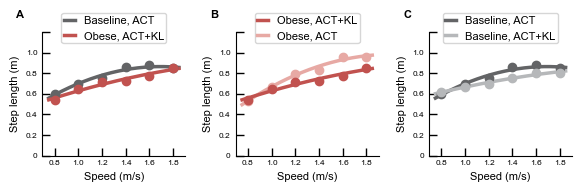

In [ ]:
# Figure 5
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.lines import Line2D


# === Set global font to Arial ===
mpl.rcParams['font.family'] = 'Arial'

# Shared speed array
speed = np.array([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
speed_smooth = np.linspace(0.75, 1.85, 300)

# Marker size
marker_size = 5

# Common text positions
letter_x = -0.18
letter_y_top = 1.10
letter_y_lower = 1.10
title_y = 1.16
subtitle_y = 1.05

title_fs = 8
label_fs = 8
tick_fs = 6
legend_fs = 8
subtitle_fs = 8
letter_fs = 8

# --- Data for (A) Step Length ---

normal_SL = load_normal_sl()
obese_SL = load_obese_sl()
poly_SL_normal = np.poly1d(np.polyfit(speed, normal_SL, 2))
poly_SL_obese = np.poly1d(np.polyfit(speed, obese_SL, 2))
smooth_SL_normal = poly_SL_normal(speed_smooth)
smooth_SL_obese = poly_SL_obese(speed_smooth)


# --- Data for (B) Step Length (New) ---
normal_SL_F = load_normal_sl_F()
obese_SL_F  = load_obese_sl()
poly_SL_normal_F = np.poly1d(np.polyfit(speed, normal_SL_F, 2))
poly_SL_obese_F  = np.poly1d(np.polyfit(speed, obese_SL_F, 2))
smooth_SL_normal_F = poly_SL_normal_F(speed_smooth)
smooth_SL_obese_F  = poly_SL_obese_F(speed_smooth)


# --- Data for (C) Step Length ---
normal_SL_I = load_normal_sl()
obese_SL_I = load_obese_sl_I()
poly_SL_normal_I = np.poly1d(np.polyfit(speed, normal_SL_I, 2))
poly_SL_obese_I = np.poly1d(np.polyfit(speed, obese_SL_I, 2))
smooth_SL_normal_I = poly_SL_normal_I(speed_smooth)
smooth_SL_obese_I = poly_SL_obese_I(speed_smooth)

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(5.76, 1.84))

color_black =  '#636466' # black
color_red =   '#C1524F' # red 
color_light_red =  '#e7a9a4'  # light red
color_light_black = '#b6b8ba' # light black

line_normal = Line2D([], [], color=color_black, linewidth=2.5, label='Baseline, ACT')
line_obese = Line2D([], [], color=color_red, linewidth=2.5, label='Obese, ACT+KL')

line_obese_act = Line2D([], [], color=color_light_red, linewidth=2.5, label='Obese, ACT')
line_obese_actkl = Line2D([], [], color=color_red, linewidth=2.5, label='Obese, ACT+KL')

line_nonobese_act = Line2D([], [], color=color_black, linewidth=2.5, label='Baseline, ACT')
line_nonobese_actkl = Line2D([], [], color=color_light_black, linewidth=2.5, label='Baseline, ACT+KL')


title_font = {'fontsize': 8, 'fontweight': 'bold'}
label_font = {'fontsize': 8, 'fontweight': 'normal'}

title_fs = 8
tick_fs = 6
legend_fs = 8
subtitle_fs = 7
letter_fs = 8

# Common text positions
letter_x = -0.18
letter_y_top = 1.10
title_y = 1.16
subtitle_y = 1.08

# ========== (A) ==========
axes[0].plot(speed_smooth, smooth_SL_normal, '-', color=color_black, linewidth=2.5, label='Baseline, ACT')
axes[0].plot(speed_smooth, smooth_SL_obese, '-', color=color_red, linewidth=2.5, label='Obese, ACT+KL')
axes[0].plot(speed, normal_SL, 'o', color=color_black)
axes[0].plot(speed, obese_SL, 'o', color=color_red)
axes[0].set_xlabel('Speed (m/s)', fontsize=8)
axes[0].set_ylabel('Step length (m)', fontsize=8)
axes[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
axes[0].set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0', ''])
axes[0].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[0].tick_params(axis='both', labelsize=6, direction='in', length=6, width=1)
axes[0].text(letter_x, letter_y_top, "A", transform=axes[0].transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')
#axes[0].legend(loc='upper left', frameon=True, fontsize=8, bbox_to_anchor=(0, 1.2))
axes[0].legend(
    handles=[line_normal, line_obese],
    loc='upper center',
    fontsize=legend_fs,
    frameon=True,
    borderpad=0.2,
    handlelength=1,
    bbox_to_anchor=(0.5, 1.2))


axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ========== (B) ==========
axes[1].plot(speed_smooth, smooth_SL_normal_F, '-', color=color_light_red, linewidth=2.5, label='Obese ACT')
axes[1].plot(speed_smooth, smooth_SL_obese_F, '-', color=color_red, linewidth=2.5, label='Obese, ACT+KL')
axes[1].plot(speed, normal_SL_F, 'o', color=color_light_red)
axes[1].plot(speed, obese_SL_F, 'o', color=color_red)
axes[1].set_xlabel('Speed (m/s)', fontsize=8)
axes[1].set_ylabel('Step length (m)', fontsize=8)
axes[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
axes[1].set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0', ''])
axes[1].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[1].tick_params(axis='both', labelsize=6, direction='in', length=6, width=1)
axes[1].text(letter_x, letter_y_top, "B", transform=axes[1].transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')
#axes[1].legend(loc='upper left', frameon=True, fontsize=8, bbox_to_anchor=(0, 1.2))
axes[1].legend(
    handles=[line_obese_actkl, line_obese_act],
    loc='upper center',
    fontsize=legend_fs,
    frameon=True,
    borderpad=0.2,
    handlelength=1,
    bbox_to_anchor=(0.5, 1.2)
)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# ========== (C) ==========
axes[2].plot(speed_smooth, smooth_SL_normal_I, '-', color=color_black, linewidth=2.5, label='Baseline, ACT')
axes[2].plot(speed_smooth, smooth_SL_obese_I, '-', color=color_light_black, linewidth=2.5, label='Baseline, ACT+KL')
axes[2].plot(speed, normal_SL_I, 'o', color=color_black)
axes[2].plot(speed, obese_SL_I, 'o', color=color_light_black)
axes[2].set_xlabel('Speed (m/s)', fontsize=8)
axes[2].set_ylabel('Step length (m)', fontsize=8)
axes[2].set_ylim(0, 1.2)
axes[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
axes[2].set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0', ''])
axes[2].set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8])
axes[2].tick_params(axis='both', labelsize=6, direction='in', length=6, width=1)
axes[2].text(letter_x, letter_y_top, "C", transform=axes[2].transAxes, fontsize=letter_fs, fontweight='bold', ha='left', va='bottom')
#axes[2].legend(loc='upper left', frameon=True, fontsize=8, bbox_to_anchor=(0, 1.2))
axes[2].legend(
    handles=[line_nonobese_act, line_nonobese_actkl],
    loc='upper center',
    fontsize=legend_fs,
    frameon=True,
    borderpad=0.2,
    handlelength=1,
    bbox_to_anchor=(0.5, 1.2)
)

axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

# --- Layout and display ---
plt.subplots_adjust(top=0.85, bottom=0.18, left=0.06, right=0.98, wspace=0.35)
plt.savefig("Figure5.tiff", dpi=1000, bbox_inches='tight')
plt.show()


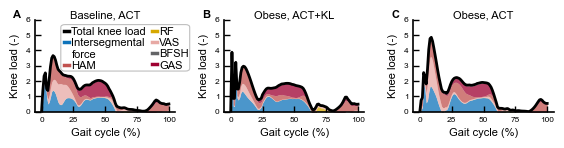

In [ ]:
#Figure 6 - Knee force components

from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.patches import FancyBboxPatch


class HandlerLine2DTop(HandlerLine2D):
    def create_artists(
        self, legend, orig_handle, xdescent, ydescent,
        width, height, fontsize, trans
    ):
        artists = super().create_artists(
            legend, orig_handle, xdescent, ydescent,
            width, height, fontsize, trans
        )

        for artist in artists:
            ydata = artist.get_ydata()
            artist.set_ydata(np.full_like(ydata, height * 1.4, dtype=float))

        return artists


def plot_knee_force_components(
    ax,
    gait_phase,
    interseg,
    rf,
    vas,
    ham,
    gas,
    bfsh,
    total,
    panel_label,
    condition_heading,
    show_ylabel=False,
    show_legend=False
):
    gait_phase = np.asarray(gait_phase)
    interseg = np.asarray(interseg)
    rf = np.asarray(rf)
    vas = np.asarray(vas)
    ham = np.asarray(ham)
    gas = np.asarray(gas)
    bfsh = np.asarray(bfsh)
    total = np.asarray(total)

    components = np.vstack([interseg, rf, vas, ham, gas, bfsh]).T
    cum = np.cumsum(components, axis=1)

    colors = [
        "#0E73BA",  # Intersegmental
        "#D6A800",  # RF
        "#e7a9a4",  # VAS
        "#C1524F",  # HAM
        "#9E0031",  # GAS
        "#636466",  # BFSH
    ]

    labels = [
        "Intersegmental force",
        "RF",
        "VAS",
        "HAM",
        "GAS",
        "BFSH",
    ]

    base = np.zeros_like(gait_phase, dtype=float)

    for i in range(cum.shape[1]):
        ax.fill_between(
            gait_phase,
            base,
            cum[:, i],
            color=colors[i],
            alpha=0.75,
            linewidth=0,
            label=labels[i]
        )
        base = cum[:, i]

    ax.plot(gait_phase, total, "k-", linewidth=2, label="Total knee load")

    ax.set_xlabel("Gait cycle (%)", fontsize=8)
    ax.set_ylabel("Knee load (-)", fontsize=8)

    ax.set_ylim(0, 6)
    ax.set_yticks([0, 1, 2, 3, 4, 5, 6])
    ax.tick_params(labelsize=6, direction="in", length=4, width=1)
    ax.tick_params(axis="y", labelleft=True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    header_y = 1

    ax.text(
        -0.16, header_y, panel_label,
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False
    )

    ax.text(
        0.5, header_y, condition_heading,
        transform=ax.transAxes,
        fontsize=8,
        fontweight="normal",
        ha="center",
        va="bottom",
        clip_on=False
    )

    if show_legend:
    
        interseg_handle = Line2D(
        [0], [0],
        color="#0E73BA",
        lw=2.5,
        label="Intersegmental\nforce"
        )
     
        blank = Line2D([0], [0], color="none", lw=0, label=" ")

        legend_handles = [
            Line2D([0], [0], color="black", lw=2.5, label="Total knee load"),
            interseg_handle,
            Line2D([0], [0], color="#C1524F", lw=2.5, label="HAM"),
            blank,
            Line2D([0], [0], color="#D6A800", lw=2.5, label="RF"),
            Line2D([0], [0], color="#e7a9a4", lw=2.5, label="VAS"),
            Line2D([0], [0], color="#636466", lw=2.5, label="BFSH"),
            Line2D([0], [0], color="#9E0031", lw=2.5, label="GAS"),
        ]
       
        leg = ax.legend(
            handles=legend_handles,
            loc="upper right",
            fontsize=8,
            frameon=False,
            bbox_to_anchor=(1.15, 1),
            handlelength=0.5,
            handletextpad=0.2,
            labelspacing=0.1,
            borderpad=0.15,
            columnspacing=0.5,
            ncol=2,
            handler_map={interseg_handle: HandlerLine2DTop()}
        )

        legend_box = FancyBboxPatch(
            (0.193, 0.45),      # x, y 위치
            0.9,             # width
            0.485,             # height
            boxstyle="round,pad=0.01,rounding_size=0.03",
            transform=ax.transAxes,
            facecolor="white",
            edgecolor="#BFBFBF",
            linewidth=0.8,
            alpha=1.0,
            clip_on=False,
            zorder=leg.get_zorder() - 1
        )

        legend_box.set_in_layout(False)
        ax.add_patch(legend_box)
        leg.set_in_layout(False)


def load_knee_force_data(excel_path):
    df = pd.read_excel(excel_path, sheet_name="Sheet1").sort_values("Gait Cycle")
    return {
        "gait_phase": df["Gait Cycle"].to_numpy(),
        "interseg": df["interseg"].to_numpy(),
        "rf": df["RF"].to_numpy(),
        "vas": df["VAS"].to_numpy(),
        "ham": df["HAM"].to_numpy(),
        "gas": df["GAS"].to_numpy(),
        "bfsh": df["BFSH"].to_numpy(),
        "total": df["Total"].to_numpy(),
    }


datasets = [
    ("Knee Force_80kg_ACT.xlsx", "A", "Baseline, ACT"),
    ("Knee Force_140kg_ACT+KL.xlsx", "B", "Obese, ACT+KL"),
    ("Knee Force_140kg_ACT.xlsx", "C", "Obese, ACT"),
]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5.76, 1.84), sharey=False)

for i, (file_name, panel_label, condition_heading) in enumerate(datasets):
    data = load_knee_force_data(file_name)
    plot_knee_force_components(
        axes[i],
        data["gait_phase"],
        data["interseg"],
        data["rf"],
        data["vas"],
        data["ham"],
        data["gas"],
        data["bfsh"],
        data["total"],
        panel_label=panel_label,
        condition_heading=condition_heading,
        show_legend=(i == 0)
    )

plt.subplots_adjust(left=0.08, right=0.98, bottom=0.2, top=0.7, wspace=0.35)
plt.savefig("Figure6.tiff", dpi=1000, bbox_inches="tight")
plt.show()
